# Clasificación y explicabilidad temporal de la demanda en restaurantes con TSInterpret

## Autores

Gianfranco Caschetto — Máster en Inteligencia Artificial, UCM (2025/26)

## Resumen

Este capítulo usa TSInterpret para explicar un clasificador de demanda diaria en Triplek,
una cadena de comida rápida en Venezuela. Con ventanas de 14 días de pedidos, el modelo
predice si el día siguiente será de alta demanda o normal. El histórico
real del CSV cubre 258 días (junio 2025 – marzo 2026). El clasificador es un Random Forest;
las explicaciones combinan LEFTIST y contrafactuales NUN-CF.



## 1. Introducción

### Explicar series temporales

SHAP, LIME o PDP asumen tablas: una fila, un vector de variables. En una serie el
orden importa y la pregunta pasa a ser qué instantes del pasado condicionan la predicción.

TSInterpret está pensado para eso. LEFTIST, TSEvo o NativeGuide devuelven importancia
por timestep, no por columnas sueltas.

### Clasificación de demanda

Triplek registra pedidos por día. Modelamos si el día siguiente será de alta demanda
o normal a partir de los 14 anteriores:

```
Entrada: últimos 14 días de pedidos
Salida:  alta demanda (sí / no)
```

### Datos

La exportación tiene 17.582 pedidos en 258 días con actividad (23-jun-2025 a 08-mar-2026).
Eso da unas 244 ventanas deslizantes; reservamos las últimas 60 para test.



In [1]:
# pip install -r requirements.txt  (tsinterpret y dependencias)

import os, types, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import euclidean_distances
from TSInterpret.InterpretabilityModels.leftist.leftist import LEFTIST

os.makedirs('figuras', exist_ok=True)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Entorno listo.')


Entorno listo.


## 2. Datos

### Pedidos

La fuente es el sistema interno de una hamburgueserías (La Viña y Centro). El CSV anonimizado
incluye 17.582 pedidos entre junio de 2025 y marzo de 2026. Agregamos por día la variable
`n_orders`.

### Anonimización

Se quitaron teléfono, nombre, correo y dirección. `order_id` es un índice secuencial.



In [2]:
df = pd.read_csv('data/triplekb-orders-anonymized.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

daily = (
    df.groupby('order_date')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'n_orders'})
    .sort_values('order_date')
    .reset_index(drop=True)
)

series_all = daily['n_orders'].values.astype(float)
date_idx = daily['order_date']

print(f'Pedidos en exportación: {len(df):,}')
print(f'Días con demanda registrada: {len(daily)}')
print(f'Rango: {daily["order_date"].min().date()} → {daily["order_date"].max().date()}')
print('\nPedidos por día (resumen):')
print(daily['n_orders'].describe().round(1).to_string())



Pedidos en exportación: 17,582
Días con demanda registrada: 258
Rango: 2025-06-23 → 2026-03-08

Pedidos por día (resumen):
count    258.0
mean      68.1
std       47.5
min        1.0
25%       40.0
50%       64.0
75%       99.5
max      182.0


### Exploración: serie diaria y día de la semana


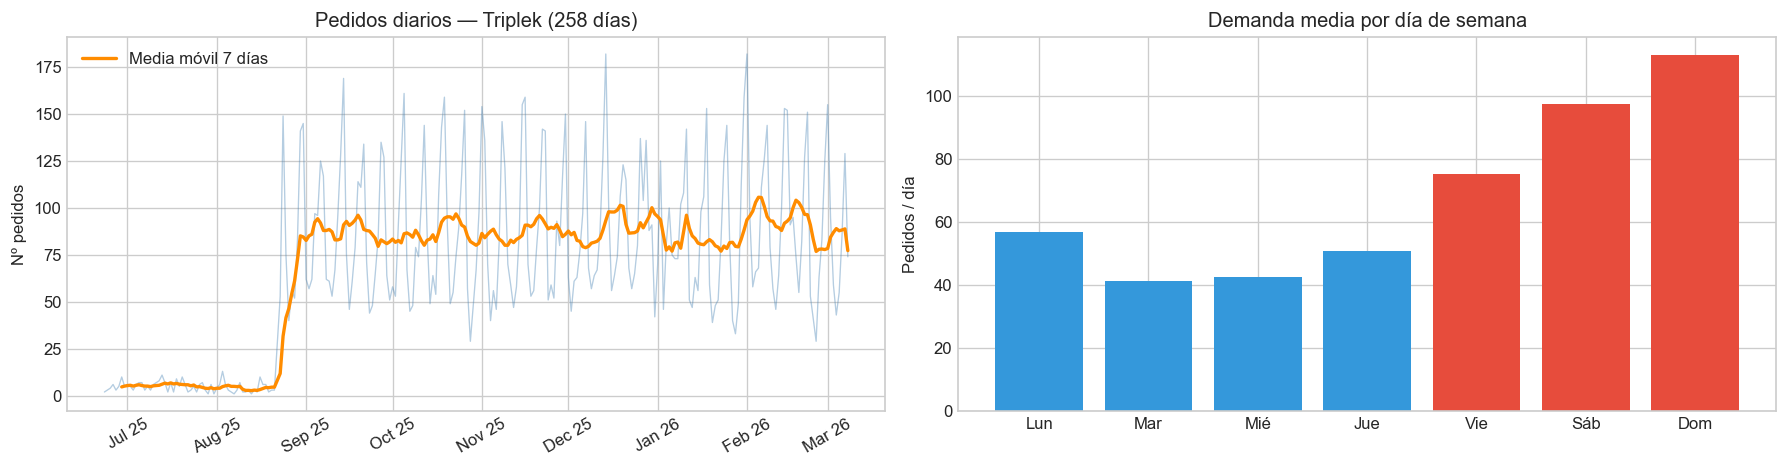

Mayor media semanal: Dom (113.2 pedidos/día)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

ax = axes[0]
ax.plot(daily['order_date'], daily['n_orders'], alpha=0.4, color='steelblue', lw=0.8)
roll = daily.set_index('order_date')['n_orders'].rolling(7).mean()
ax.plot(roll.index, roll.values, color='darkorange', lw=2, label='Media móvil 7 días')
ax.set_title(f'Pedidos diarios — Triplek ({len(daily)} días)')
ax.set_ylabel('Nº pedidos')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.get_xticklabels(), rotation=30)

ax2 = axes[1]
dias_es = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
por_dia = daily.assign(dow=daily['order_date'].dt.dayofweek).groupby('dow')['n_orders'].mean()
colors = ['#e74c3c' if i >= 4 else '#3498db' for i in range(7)]
ax2.bar(dias_es, por_dia.values, color=colors)
ax2.set_title('Demanda media por día de semana')
ax2.set_ylabel('Pedidos / día')

plt.tight_layout()
plt.savefig('figuras/01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mayor media semanal: {dias_es[por_dia.idxmax()]} ({por_dia.max():.1f} pedidos/día)')



En la figura 1, a la izquierda se ve la serie diaria con la media móvil de una semana en naranja:
suaviza el ruido y deja claro que hay ondas repetidas cada pocos días. A la derecha, el domingo
se lleva la mayor media (unos 113 pedidos), casi el doble que un día entre semana. Por eso
tiene sentido mirar dos semanas hacia atrás cuando predecimos el día siguiente.


## 3. Serie de demanda diaria

Revisamos tendencia y estacionalidad semanal con descomposición aditiva (periodo 7)
sobre los 258 días reales agregados del CSV.



Serie de demanda: 258 días | media=68.1 | std=47.4


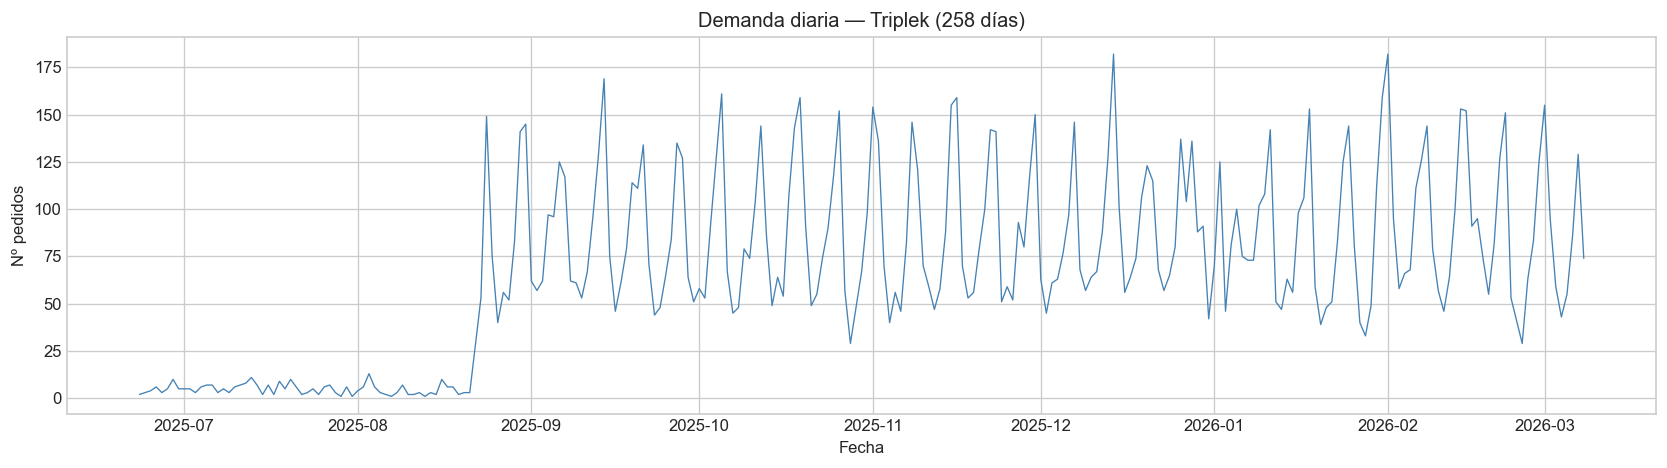

In [4]:
series_pd = pd.Series(series_all, index=date_idx)

print(f'Serie de demanda: {len(series_all)} días | media={series_all.mean():.1f} | std={series_all.std():.1f}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(date_idx, series_all, color='steelblue', lw=0.8)
ax.set_title(f'Demanda diaria — Triplek ({len(daily)} días)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Nº pedidos')
plt.tight_layout()
plt.savefig('figuras/02_serie_historica.png', dpi=150, bbox_inches='tight')
plt.show()



La figura 2 recorre los 258 días completos. Hay mucha dispersión (desde días casi vacíos hasta
picos de más de 180 pedidos) y un ritmo que se repite: subidas en fin de semana y bajadas en
entre semana. No parece una tendencia lineal fuerte en nueve meses; si hubiera estacionalidad
anual, harían falta más años para verla con calma.


## 4. Ventanas y etiquetas

Cada instancia usa 14 días como entrada y el día siguiente como objetivo. La etiqueta
alta demanda es el tercio superior de pedidos/día (percentil 67 calculado en el histórico):

```
X_i = [n_{i-14}, ..., n_{i-1}]
y_i = 1  si  n_i >= percentil_67
```

TSInterpret espera `(muestras, 14, 1)`. Split temporal: últimas 60 instancias en test.



In [5]:
WINDOW = 14   # 2 semanas de pasado

def create_windows(series, w):
    X, y = [], []
    for i in range(w, len(series)):
        X.append(series[i-w:i])
        y.append(series[i])
    return np.array(X), np.array(y)

X_all, y_reg = create_windows(series_all, WINDOW)

# Umbral de clasificación: percentil 67 (≈ top tercio)
THRESHOLD = np.percentile(y_reg, 67)
y_clf = (y_reg >= THRESHOLD).astype(int)

print(f"Instancias creadas: {X_all.shape[0]}")
print(f"Umbral ALTA demanda: {THRESHOLD:.0f} pedidos/día")
print(f"Distribución: {y_clf.mean():.1%} días ALTA | {1-y_clf.mean():.1%} días NORMAL")

# Split temporal: últimas 60 instancias como test
SPLIT = len(X_all) - 60
X_train_2d, X_test_2d = X_all[:SPLIT],  X_all[SPLIT:]
y_train,    y_test     = y_clf[:SPLIT],  y_clf[SPLIT:]

# Formato 3D para TSInterpret: (n, time, 1)
X_train_3d = X_train_2d.reshape(-1, WINDOW, 1)
X_test_3d  = X_test_2d.reshape(-1, WINDOW, 1)

print(f"\nTrain: {len(X_train_2d)} instancias")
print(f"Test:  {len(X_test_2d)} instancias")
print(f"Forma TSInterpret: {X_train_3d.shape}")


Instancias creadas: 244
Umbral ALTA demanda: 88 pedidos/día
Distribución: 34.0% días ALTA | 66.0% días NORMAL

Train: 184 instancias
Test:  60 instancias
Forma TSInterpret: (184, 14, 1)


## 5. Modelo

Random Forest (200 árboles, profundidad 8). Se entrena en `(n, 14)`; para LEFTIST
envolvemos `predict_proba` para aceptar `(batch, 14, 1)`.


=== Evaluación en test ===
              precision    recall  f1-score   support

  Normal (0)       0.86      0.88      0.87        34
    Alta (1)       0.84      0.81      0.82        26

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



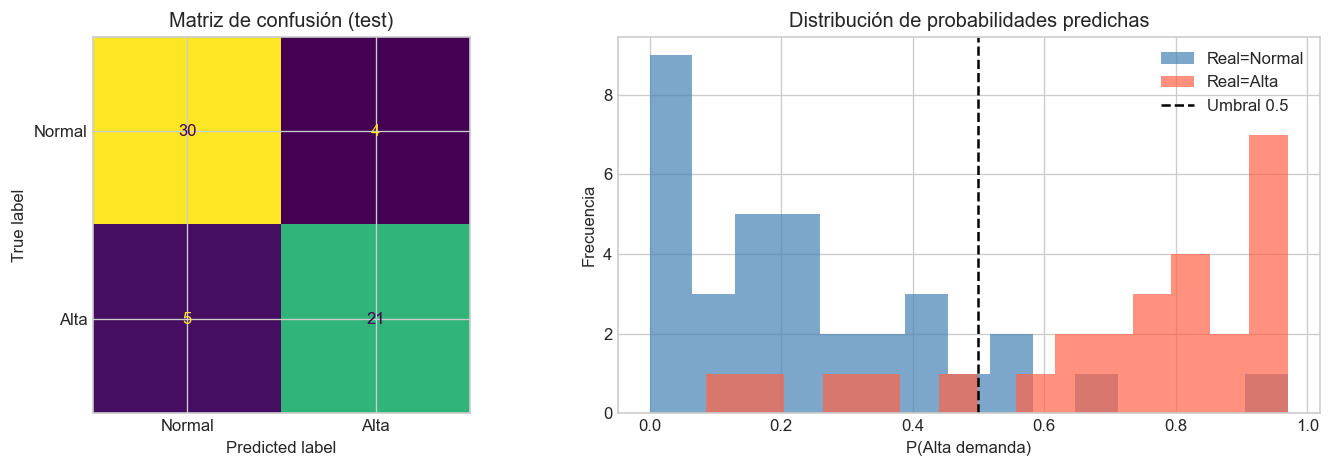

In [6]:
clf = RandomForestClassifier(n_estimators=200, max_depth=8,
                              random_state=RANDOM_STATE, n_jobs=-1)
clf.fit(X_train_2d, y_train)
y_pred = clf.predict(X_test_2d)
y_proba = clf.predict_proba(X_test_2d)

print("=== Evaluación en test ===")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Alta (1)']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal','Alta']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión (test)')

# Probabilidades predichas
axes[1].hist(y_proba[y_test==0, 1], bins=15, alpha=0.7, color='steelblue', label='Real=Normal')
axes[1].hist(y_proba[y_test==1, 1], bins=15, alpha=0.7, color='tomato',    label='Real=Alta')
axes[1].axvline(0.5, color='black', ls='--', lw=1.5, label='Umbral 0.5')
axes[1].set_xlabel('P(Alta demanda)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de probabilidades predichas')
axes[1].legend()

plt.tight_layout()
plt.savefig('figuras/03_evaluacion_modelo.png', dpi=150, bbox_inches='tight')
plt.show()



En la figura 3, la matriz de la izquierda resume el test: 51 aciertos de 60 (85 %). Falla un poco
más en días altos (21 de 26) que en normales (30 de 34). A la derecha, las probabilidades se
separan bastante bien: los normales quedan con P(alta) baja y los altos se acercan a 1, aunque
en el centro hay mezcla y ahí salen los errores.


## 6. Explicaciones con TSInterpret

Usamos dos vías:

| Método | Qué responde |
|--------|----------------|
| LEFTIST | Qué días del pasado empujaron la clase predicha |
| NUN-CF (manual) | Qué ventana del train de la otra clase se parece más |

En la versión 0.4.7 de TSInterpret, TSEvo, COMTECF y NativeGuideCF fallan con Python 3.12
y backends sklearn; NUN-CF lo implementamos a mano siguiendo Delaney et al. (2021).


### 6.1 LEFTIST

LEFTIST segmenta la ventana, perturba cada tramo (media del segmento) y estima
contribución con LIME. El mapa positivo favorece alta demanda; el negativo, normal.

Corrección local en `_shape_explanations` (v0.4.7): `values_per_slice` debe ser
`len(series) // nb_interpretable_feature`, no `nb_interpretable_feature`. Patch con
`types.MethodType` sin tocar el paquete instalado.


In [7]:
# Función de predicción compatible con el formato 3D de TSInterpret
# TSInterpret pasa (batch, time, feat); sklearn necesita (batch, time*feat)
def predict_fn(item):
    return clf.predict_proba(item.reshape(item.shape[0], -1))

# Verificación
test_batch = X_test_3d[:3]
proba = predict_fn(test_batch)
print(f"predict_fn: {test_batch.shape} → {proba.shape}  ✓")

# ── Patch del bug de _shape_explanations ──────────────────────────────────
N_SEGMENTS = 7   # 7 segmentos de 2 días cada uno (14 días / 7 = 2)

def fixed_shape_explanations(self, explanations, series):
    """Corrige values_per_slice = len(series) // nb_interpretable_feature."""
    n_seg    = self.nb_interpretable_feature
    seg_size = max(1, len(series) // n_seg)
    heatmaps = []
    for i in range(len(explanations)):
        heatmap = np.zeros(len(series))
        j = 0
        for value in explanations[i][0]:
            end = min(j + seg_size, len(heatmap))
            heatmap[j:end] = float(value)
            j = end
            if j >= len(heatmap):
                break
        heatmaps.append(heatmap)
    return heatmaps

# Inicializar LEFTIST
leftist = LEFTIST(
    model=predict_fn,
    data=(X_train_3d, y_train),
    mode='time',
    backend='F',                       # F = función directa (no SK/TF/PYT)
    nb_interpretable_feature=N_SEGMENTS,
    transform_name='mean',             # perturba reemplazando segmento con su media
    learning_process_name='Lime',
    nb_neighbors=1000,
    explanation_size=N_SEGMENTS,       # retorna peso para todos los segmentos
)
# Aplicar patch
leftist._shape_explanations = types.MethodType(fixed_shape_explanations, leftist)
print("LEFTIST inicializado con patch aplicado.")


predict_fn: (3, 14, 1) → (3, 2)  ✓
The Predict Function was given directly
LEFTIST inicializado con patch aplicado.


In [8]:
def plot_leftist_heatmap(ax, instance_2d, heatmap, pred_class, true_class,
                          title='', window=14, threshold=THRESHOLD):
    """Visualiza la ventana temporal con heatmap LEFTIST superpuesto."""
    timesteps = np.arange(window)
    labels    = [f't-{window-i}' for i in range(window)]

    # Heatmap de fondo (colores) — TwoSlopeNorm requiere vmin < 0 < vmax
    h_min, h_max = heatmap.min(), heatmap.max()
    if h_max <= 0:
        norm = mcolors.Normalize(vmin=h_min, vmax=0)
    elif h_min >= 0:
        norm = mcolors.Normalize(vmin=0, vmax=max(h_max, 1e-9))
    else:
        norm = mcolors.TwoSlopeNorm(vmin=h_min, vcenter=0, vmax=h_max)
    cmap = plt.cm.RdYlBu_r

    # Barras de importancia en el fondo
    for t in range(window):
        color = cmap(norm(heatmap[t]))
        ax.axvspan(t - 0.5, t + 0.5, alpha=0.4, color=color, zorder=1)

    # Serie temporal
    ax.plot(timesteps, instance_2d, 'o-', color='black', lw=1.5, ms=5, zorder=3)

    # Línea de umbral
    ax.axhline(threshold, color='red', ls='--', lw=1, alpha=0.8, label=f'Umbral ALTA={threshold:.0f}')

    ax.set_xticks(timesteps)
    ax.set_xticklabels(labels, rotation=45, fontsize=8)
    ax.set_ylabel('Pedidos/día')
    ax.legend(fontsize=8, loc='upper left')

    clase_pred = 'ALTA' if pred_class == 1 else 'NORMAL'
    clase_real = 'ALTA' if true_class == 1 else 'NORMAL'
    color_title = 'darkred' if pred_class == 1 else 'steelblue'
    ax.set_title(f'{title}\nPredicción: {clase_pred} | Real: {clase_real}',
                 fontsize=10, color=color_title)

    # Colorbar
    sm_cb = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm_cb.set_array([])
    plt.colorbar(sm_cb, ax=ax, label='Importancia LEFTIST', pad=0.01, shrink=0.8)

print("Función de visualización definida.")




Función de visualización definida.


### 6.1.1 Casos locales

Cuatro ejemplos del test bien clasificados: dos alta y dos normal.


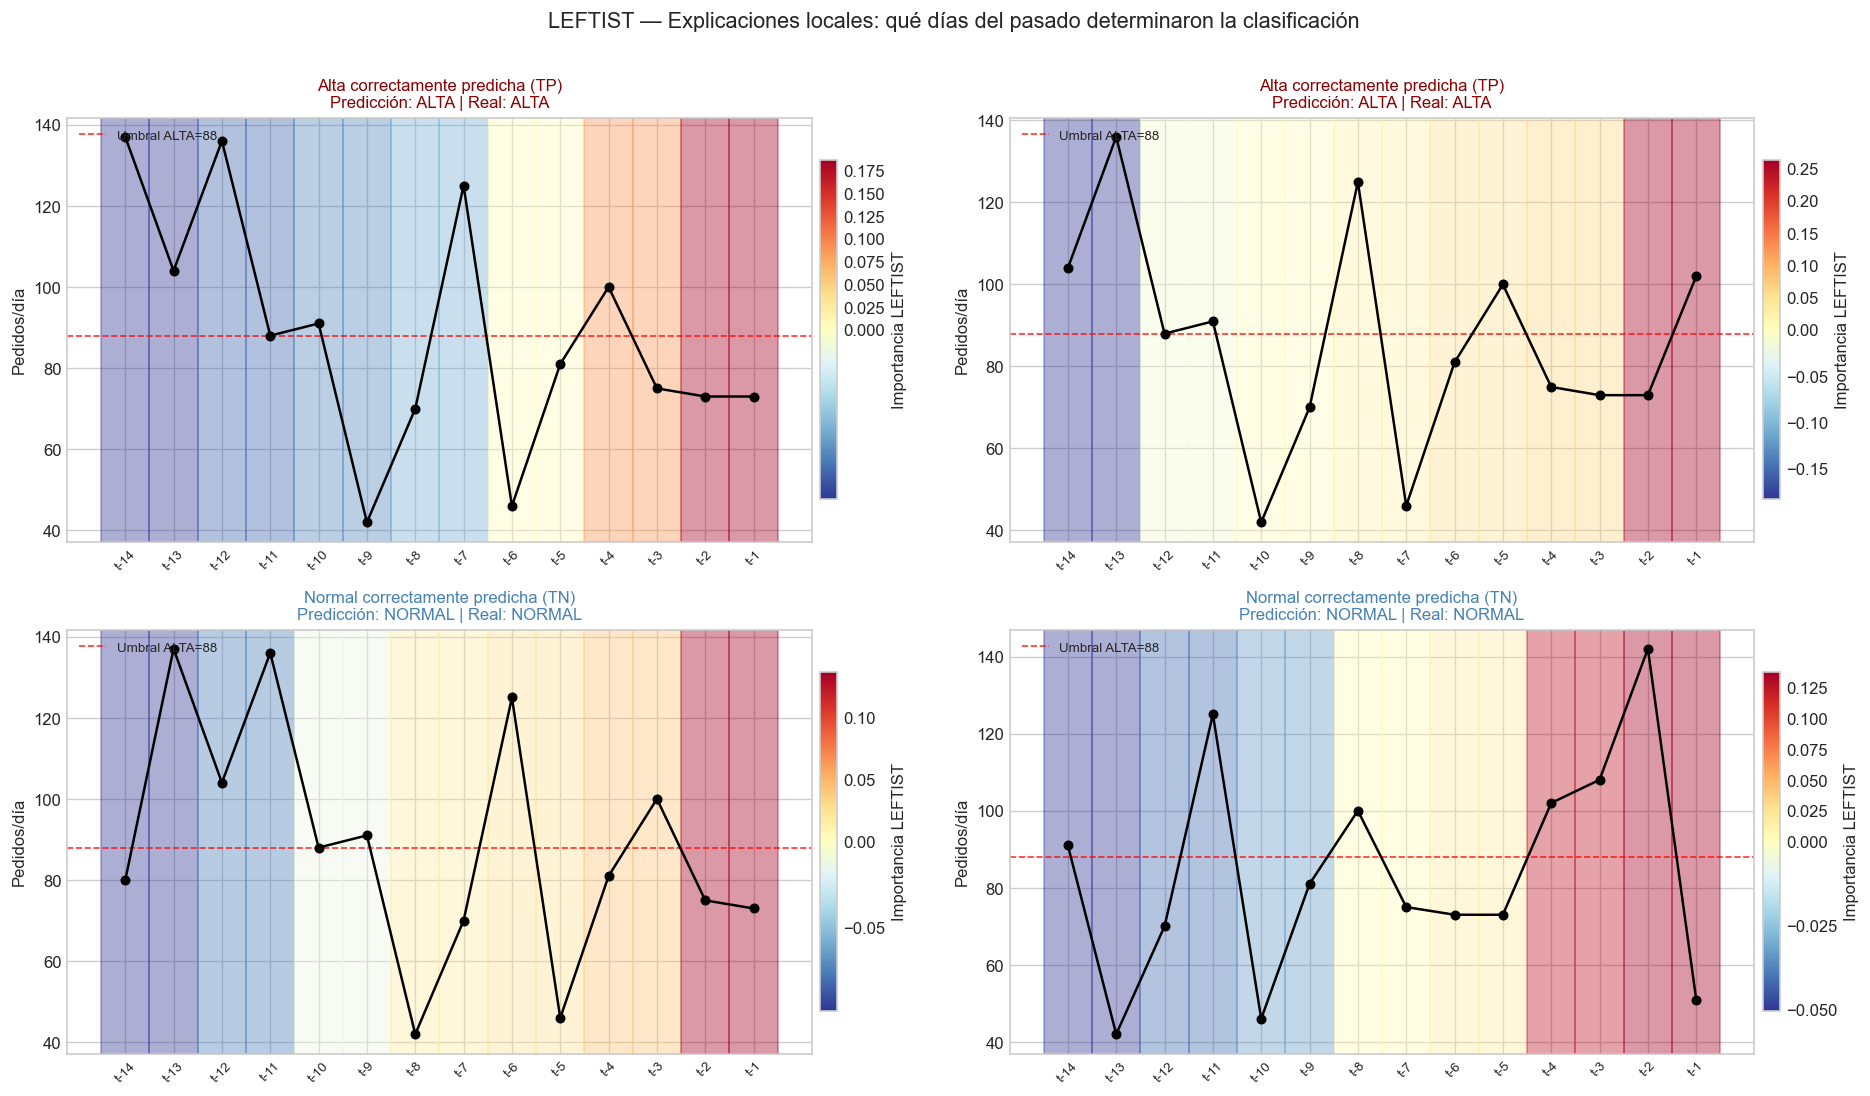

In [9]:
# Seleccionar casos representativos
idx_tp = np.where((y_test == 1) & (y_pred == 1))[0][:2]  # True Positives (Alta bien)
idx_tn = np.where((y_test == 0) & (y_pred == 0))[0][:2]  # True Negatives (Normal bien)

casos = list(idx_tp) + list(idx_tn)
titulos = ['Alta correctamente predicha (TP)', 'Alta correctamente predicha (TP)',
           'Normal correctamente predicha (TN)', 'Normal correctamente predicha (TN)']

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for ax, idx, titulo in zip(axes, casos, titulos):
    inst_3d  = X_test_3d[idx:idx+1]     # (1, 14, 1)
    inst_2d  = X_test_2d[idx]            # (14,)
    pc       = int(y_pred[idx])
    tc       = int(y_test[idx])

    # Explicar con LEFTIST
    exp = leftist.explain(inst_3d, idx_label=pc)
    heatmap = exp[0]   # shape (14,)

    plot_leftist_heatmap(ax, inst_2d, heatmap, pc, tc, title=titulo)

plt.suptitle('LEFTIST — Explicaciones locales: qué días del pasado determinaron la clasificación',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figuras/04_leftist_local.png', dpi=150, bbox_inches='tight')
plt.show()



La figura 4 muestra cuatro casos del test bien clasificados. En cada panel, la línea negra es
la ventana de 14 días y el fondo de color es LEFTIST: rojo empuja hacia alta, azul hacia normal.
Cuando el modelo acierta un día alto, suele pintar fuerte los últimos días de la ventana;
cuando acierta un normal, el mapa es más repartido o inclina al azul en esos mismos lags.


### 6.2 Importancia agregada

LEFTIST en cada acierto del test; promediamos heatmaps por clase predicha para ver
qué lags importan en conjunto.


Instancias correctamente clasificadas en test: 51


  Instancias ALTA analizadas: 21
  Instancias NORMAL analizadas: 30


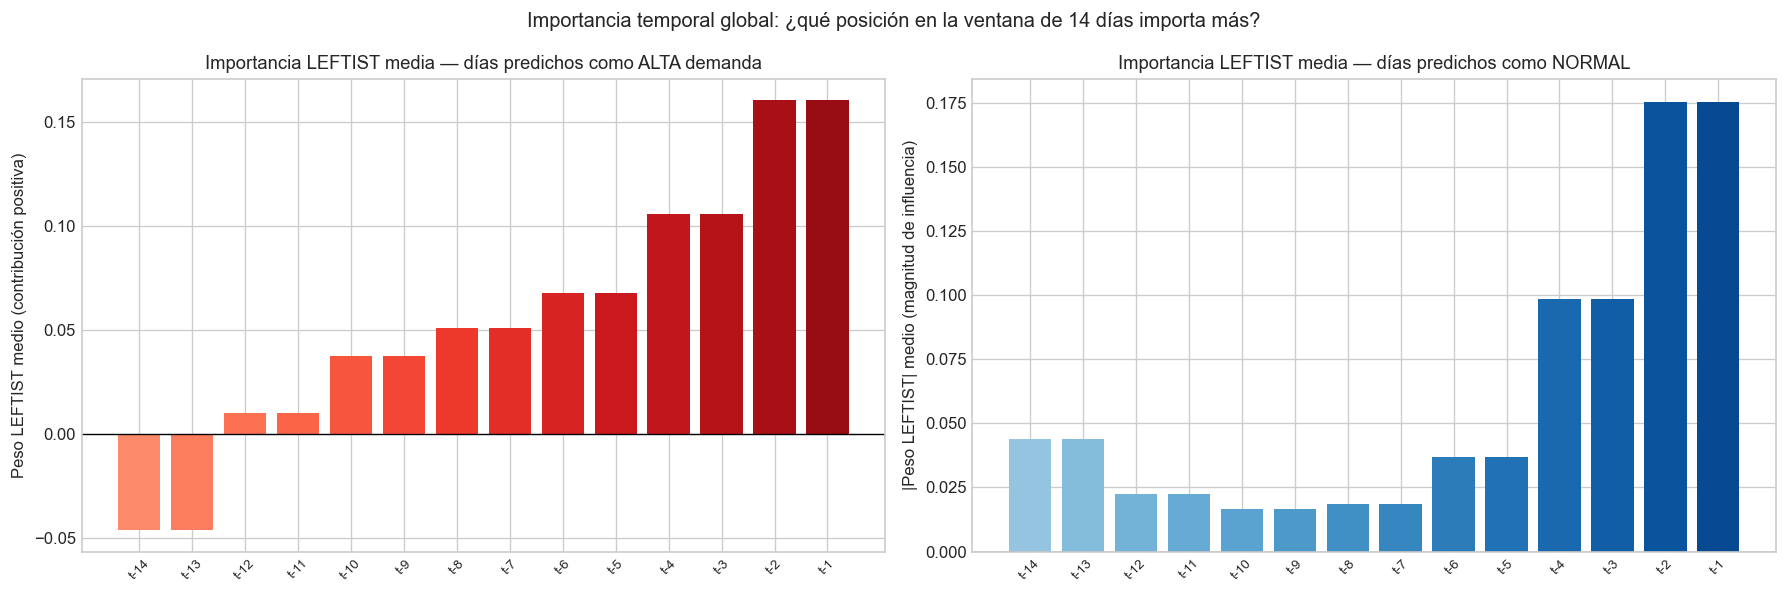


Insight: para días ALTA, el timestep más influyente es t-2
→ Los días más recientes en la ventana tienen mayor peso en predecir alta demanda.


In [10]:
# Calcular LEFTIST sobre todas las instancias del test correctamente clasificadas
correct_idx = np.where(y_pred == y_test)[0]
print(f"Instancias correctamente clasificadas en test: {len(correct_idx)}")

heatmaps_alta   = []
heatmaps_normal = []

for idx in correct_idx:
    inst_3d = X_test_3d[idx:idx+1]
    pc      = int(y_pred[idx])
    exp     = leftist.explain(inst_3d, idx_label=pc)
    h       = exp[0]

    if pc == 1:
        heatmaps_alta.append(h)
    else:
        heatmaps_normal.append(np.abs(h))  # |valor| para instancias NORMAL

mean_alta   = np.mean(heatmaps_alta,   axis=0) if heatmaps_alta   else np.zeros(WINDOW)
mean_normal = np.mean(heatmaps_normal, axis=0) if heatmaps_normal else np.zeros(WINDOW)

print(f"  Instancias ALTA analizadas: {len(heatmaps_alta)}")
print(f"  Instancias NORMAL analizadas: {len(heatmaps_normal)}")

# Visualización
lag_labels = [f't-{WINDOW-i}' for i in range(WINDOW)]
x = np.arange(WINDOW)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
ax1.bar(x, mean_alta, color=plt.cm.Reds(np.linspace(0.4, 0.9, WINDOW)))
ax1.set_xticks(x); ax1.set_xticklabels(lag_labels, rotation=45, fontsize=8)
ax1.set_title('Importancia LEFTIST media — días predichos como ALTA demanda',
              fontsize=11)
ax1.set_ylabel('Peso LEFTIST medio (contribución positiva)')
ax1.axhline(0, color='black', lw=0.8)

ax2 = axes[1]
ax2.bar(x, mean_normal, color=plt.cm.Blues(np.linspace(0.4, 0.9, WINDOW)))
ax2.set_xticks(x); ax2.set_xticklabels(lag_labels, rotation=45, fontsize=8)
ax2.set_title('Importancia LEFTIST media — días predichos como NORMAL',
              fontsize=11)
ax2.set_ylabel('|Peso LEFTIST| medio (magnitud de influencia)')
ax2.axhline(0, color='black', lw=0.8)

plt.suptitle('Importancia temporal global: ¿qué posición en la ventana de 14 días importa más?',
             fontsize=12)
plt.tight_layout()
plt.savefig('figuras/05_leftist_global.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
top_alta = np.argmax(mean_alta)
print(f"\nEn alta demanda, el lag con más peso medio suele ser t-{WINDOW - top_alta}.")




La figura 5 promedia LEFTIST en los aciertos del test. Para predicciones de alta (izquierda),
pesan sobre todo t-1 a t-4: lo que pasó esta semana y la anterior corta condiciona mucho el
siguiente día. En normales (derecha) el patrón es más plano, pero también gana importancia
hacia el final de la ventana. Encaja con que la serie tenga memoria corta y ciclo semanal.

En los días etiquetados como alta, el lag que más repite es t-2.


### 6.3 Contrafactuales NUN-CF

Dado un caso predicho como alta, buscamos en train la ventana etiquetada normal más
cercana en distancia euclídea. Esa ventana es el «pasado alternativo» más parecido que
llevaría a la otra clase según el vecino guardado en entrenamiento.


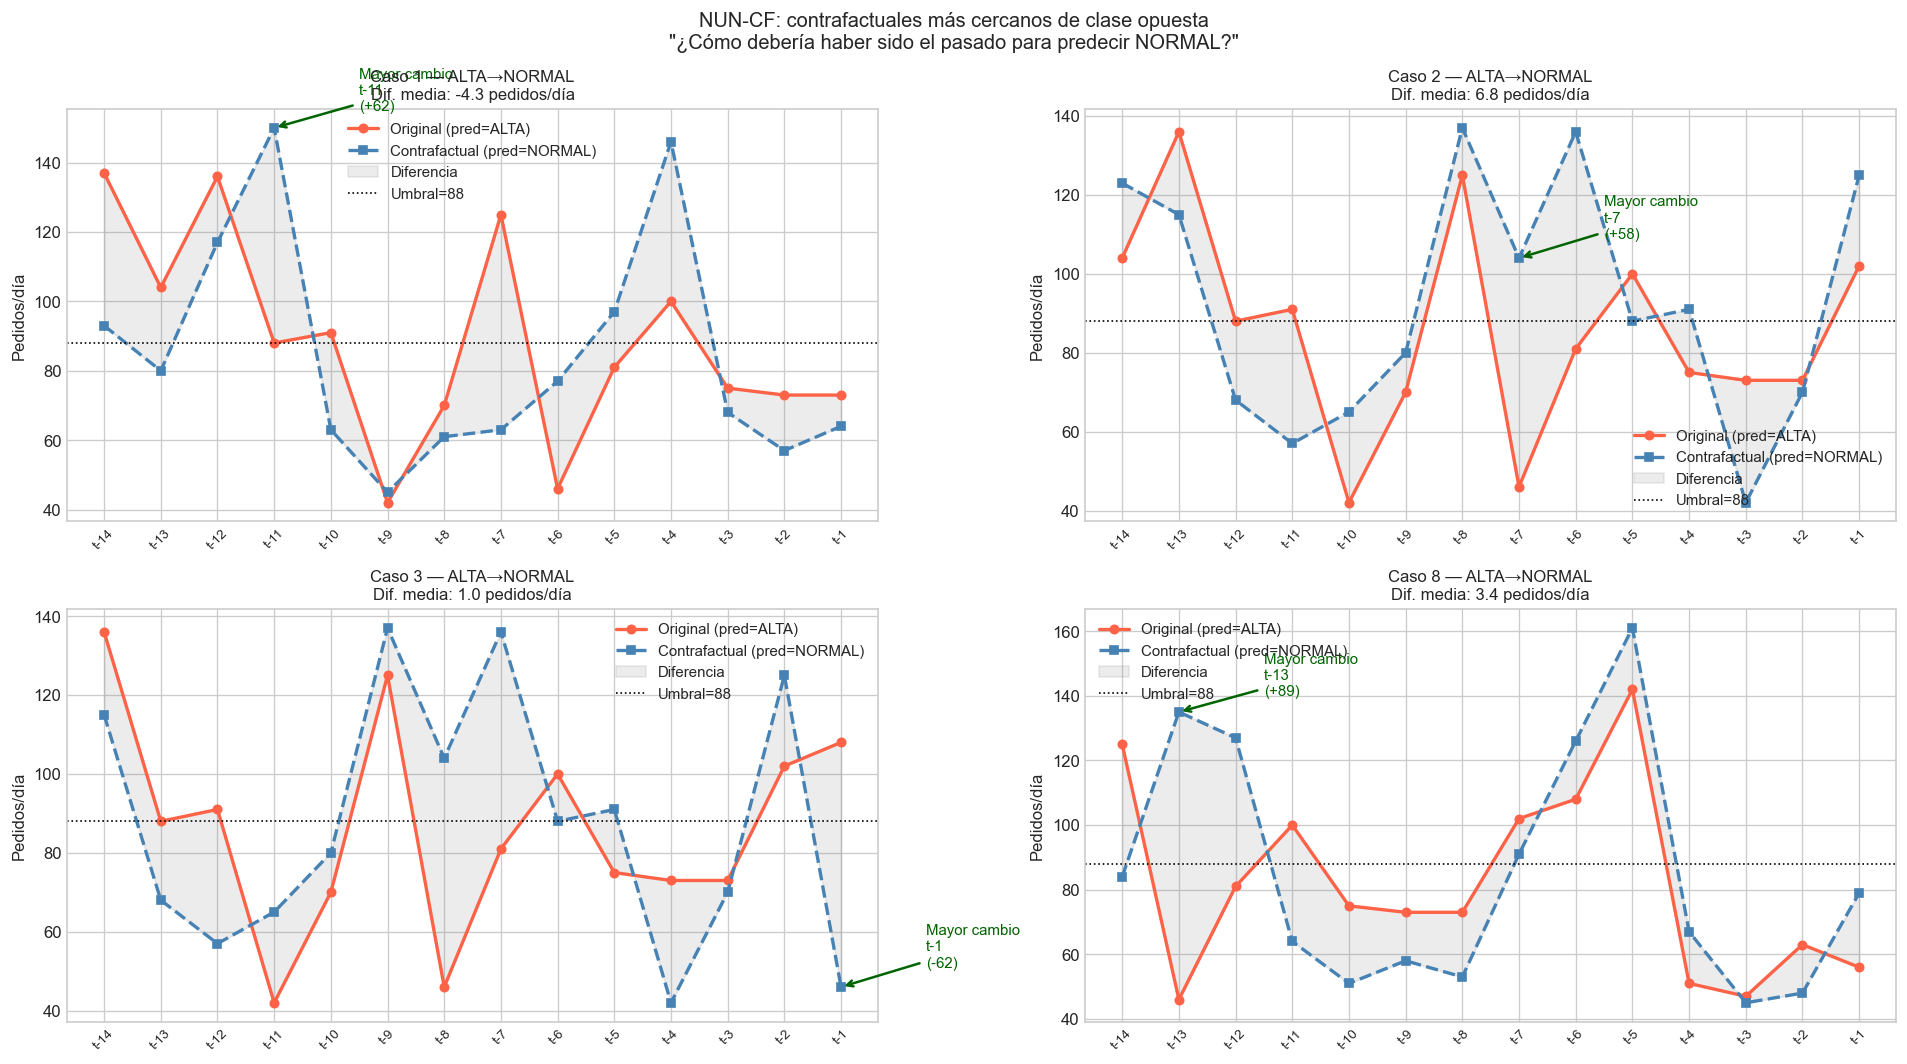

In [11]:
def nun_cf(X_train_2d, y_train, instance_2d, predicted_class):
    """Nearest Unlike Neighbor Counterfactual."""
    opposite_class = 1 - predicted_class
    mask           = y_train == opposite_class
    opposite_X     = X_train_2d[mask]
    dists = euclidean_distances(instance_2d.reshape(1, -1), opposite_X)
    best  = np.argmin(dists)
    return opposite_X[best], opposite_class

def plot_nun_cf(ax, original, counterfactual, pred_orig, pred_cf,
                window=14, threshold=THRESHOLD):
    """Visualiza original vs contrafactual."""
    t      = np.arange(window)
    labels = [f't-{window-i}' for i in range(window)]

    ax.plot(t, original,      'o-', color='tomato',    lw=2, ms=5, label=f'Original (pred={"ALTA" if pred_orig==1 else "NORMAL"})')
    ax.plot(t, counterfactual,'s--',color='steelblue', lw=2, ms=5, label=f'Contrafactual (pred={"ALTA" if pred_cf==1 else "NORMAL"})')
    ax.fill_between(t, original, counterfactual, alpha=0.15, color='grey', label='Diferencia')
    ax.axhline(threshold, color='black', ls=':', lw=1, label=f'Umbral={threshold:.0f}')
    ax.set_xticks(t); ax.set_xticklabels(labels, rotation=45, fontsize=8)
    ax.set_ylabel('Pedidos/día'); ax.legend(fontsize=9)

    delta = counterfactual - original
    max_change_idx = np.argmax(np.abs(delta))
    ax.annotate(f'Mayor cambio\nt-{window-max_change_idx}\n({delta[max_change_idx]:+.0f})',
                xy=(max_change_idx, counterfactual[max_change_idx]),
                xytext=(max_change_idx + 1.5, counterfactual[max_change_idx] + 5),
                arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
                color='darkgreen', fontsize=9)

# Analizar 4 contrafactuales
casos_cf  = list(np.where((y_pred == 1) & (y_test == 1))[0][:4])
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for ax, idx in zip(axes, casos_cf):
    inst   = X_test_2d[idx]
    pc     = int(y_pred[idx])
    cf, cf_class = nun_cf(X_train_2d, y_train, inst, pc)
    cf_pred      = int(clf.predict(cf.reshape(1, -1))[0])

    plot_nun_cf(ax, inst, cf, pc, cf_class)
    ax.set_title(f'Caso {idx} — ALTA→NORMAL\nDif. media: {(cf-inst).mean():.1f} pedidos/día',
                 fontsize=10)

plt.suptitle('NUN-CF: contrafactuales más cercanos de clase opuesta\n'
             '"¿Cómo debería haber sido el pasado para predecir NORMAL?"',
             fontsize=12)
plt.tight_layout()
plt.savefig('figuras/06_nun_cf.png', dpi=150, bbox_inches='tight')
plt.show()




La figura 6 compara cada caso predicho como alta (línea roja) con el vecino de entrenamiento
más parecido pero etiquetado como normal (azul discontinua). La zona gris es la diferencia;
la flecha verde marca el día donde más cambia el valor. No hace falta reescribir toda la
quincena: a veces bastan uno o dos días distintos para que el modelo cambie de opinión,
en la misma línea que LEFTIST marca los lags recientes.


In [12]:
print('Contrafactuales NUN-CF — casos alta bien clasificados:')
print(f"{'idx':>4} | {'media orig':>10} | {'media CF':>8} | {'Δ media':>8} | timesteps con más cambio")
print('-' * 65)

todos_alta = np.where((y_pred == 1) & (y_test == 1))[0]
for idx in todos_alta[:8]:
    inst = X_test_2d[idx]
    cf, _ = nun_cf(X_train_2d, y_train, inst, 1)
    delta = cf - inst
    top_change = np.argsort(np.abs(delta))[-2:][::-1]
    dias_key = ', '.join([f't-{WINDOW - d}' for d in top_change])
    print(f'{idx:>4} | {inst.mean():>10.1f} | {cf.mean():>8.1f} | {delta.mean():>+8.1f} | {dias_key}')



Contrafactuales NUN-CF — casos alta bien clasificados:
 idx | media orig | media CF |  Δ media | timesteps con más cambio
-----------------------------------------------------------------
   1 |       88.6 |     84.4 |     -4.3 | t-7, t-11
   2 |       86.1 |     92.9 |     +6.8 | t-7, t-6
   3 |       86.4 |     87.4 |     +1.0 | t-1, t-8
   8 |       81.6 |     84.9 |     +3.4 | t-13, t-12
   9 |       79.6 |     92.9 |    +13.3 | t-14, t-4
  10 |       83.9 |     87.4 |     +3.5 | t-1, t-5
  16 |       78.9 |     92.9 |    +14.1 | t-4, t-1
  17 |       80.1 |     87.4 |     +7.4 | t-1, t-5


### 6.4 Síntesis

LEFTIST y NUN-CF coinciden en que pesan más los días recientes de la ventana. La
clasificación de picos se parece a una racha: varios días altos seguidos empujan la
predicción; un día flojo reciente puede bajarla. En NUN-CF los cambios mayores suelen
concentrarse en los mismos lags que marca LEFTIST, aunque el vecino contrafactual no
siempre implica bajar todos los días recientes.



## 7. Conclusiones

El Random Forest alcanza unos 85 % de accuracy en el test (recall alta ~0,71).
Las explicaciones apuntan a inercia en los últimos dos o cuatro días. Los contrafactuales
suelen acercarse a ventanas con menos pedidos en ese tramo reciente.

Operativamente, sirve como alerta de continuidad de demanda, no como cifra exacta de pedidos.

Sobre TSInterpret: LEFTIST funciona bien con el patch; los contrafactuales nativos
dieron problemas en nuestro entorno y por eso NUN-CF quedó manual.

Limitaciones: al binarizar se pierde matices entre 89 y 120 pedidos; no hay calendario
de feriados ni cortes de luz; el umbral global no se recalcula por sucursal.

Trabajo futuro: probar LSTM/CNN con NativeGuide, clases baja/media/alta, y estabilidad
de las explicaciones si se reentrena el bosque.


## 8. Referencias

- Guillemé, M., et al. (2019). Agnostic local explanation for time series classification. IEEE ICTAI.
- Höllig, J., et al. (2022). TSEvo: Evolutionary Counterfactual Explanations for Time Series Classification. IEEE ICMLA.
- Delaney, E., Greene, D., & Keane, M.T. (2021). Instance-Based Counterfactual Explanations for Time Series Classification. ICCBR.
- Ribeiro, M.T., Singh, S., & Guestrin, C. (2016). "Why Should I Trust You?": Explaining the Predictions of Any Classifier. KDD.
- Höllig, J. et al. (2023). TSInterpret: A Python Package for the Interpretability of Time Series Classification. SoftwareX.
- Biecek, P., & Burzykowski, T. (2021). Explanatory Model Analysis. Chapman and Hall/CRC.
- Molnar, C. (2022). Interpretable Machine Learning (2nd ed.).
